In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

In [2]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

print(device)
print(torch.__version__)

cuda
2.13.0+cu130


In [3]:
torch.manual_seed(42)
np.random.seed(42)

In [4]:
def perceptron_and(x1, x2):
    w = torch.tensor([0.5, 0.5])  
    b = torch.tensor(-0.7)        
    x = torch.tensor([x1, x2], dtype=torch.float32)
    output = torch.dot(w, x) + b  
    return 1 if output >= 0 else 0


print(perceptron_and(0, 0))  
print(perceptron_and(0, 1))  
print(perceptron_and(1, 0))  
print(perceptron_and(1, 1))  

0
0
0
1


In [5]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # nn.Linera(들어오는 개수, 나가는 개수)
        self.fc1 = nn.Linear(2, 3)  
        self.fc2 = nn.Linear(3, 1) 

    def forward(self, x):
        x = torch.relu(self.fc1(x))      
        x = torch.sigmoid(self.fc2(x))
        return x

model = SimpleNN()
sample_input = torch.tensor([1.0, 2.0])
output = model(sample_input)
print(output)

tensor([0.6693], grad_fn=<SigmoidBackward0>)


In [6]:
class SimpleNN_Full(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNN_Full, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)   
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)  

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x
model = SimpleNN_Full(input_size=10, hidden_size=20, output_size=1)
print(model)

for param in model.parameters():
    print(param.shape)

SimpleNN_Full(
  (fc1): Linear(in_features=10, out_features=20, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=20, out_features=1, bias=True)
)
torch.Size([20, 10])
torch.Size([20])
torch.Size([1, 20])
torch.Size([1])


In [7]:
X_train = torch.randn(100, 10)
y_train = torch.randn(100, 1)
dataset = TensorDataset(X_train, y_train)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [8]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    for batch in dataloader:
        inputs, targets = batch
        optimizer.zero_grad() 
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
    print(epoch+1, loss.item())

1 0.9306033849716187
2 1.979332447052002
3 0.5246674418449402
4 0.9314338564872742
5 2.472566843032837
6 1.977538824081421
7 2.6563892364501953
8 1.100563645362854
9 1.5428667068481445
10 0.08924788981676102


In [9]:
torch.save(model.state_dict(), 'model.pth')
model = SimpleNN_Full(input_size=10, hidden_size=20, output_size=1)
model.load_state_dict(torch.load('model.pth'))

<All keys matched successfully>

In [10]:
def check_nan_loss(loss, optimizer):
    if torch.isnan(loss).any():
        print("Loss에 nan가 포함되어 있음")
        
        for param_group in optimizer.param_groups:
            param_group['lr'] *= 0.1
        return True
    return False

sample_loss = torch.tensor(float('nan'))
nan_detected = check_nan_loss(sample_loss, optimizer)
print(nan_detected)

Loss에 nan가 포함되어 있음
True


In [11]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])


In [12]:
# MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                          transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False,
                                         transform=transform, download=True)



In [13]:
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

print(len(train_loader))
print(len(test_loader))



938
10


In [14]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x



In [15]:
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [21]:
for epoch in range(10):  
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()


    print(epoch+1, loss.item())

1 0.09112518280744553
2 0.011676640249788761
3 0.004316761624068022
4 2.8177510102977976e-05
5 0.0011790723074227571
6 0.007343596313148737
7 0.00027859187684953213
8 0.03305986151099205
9 0.03234086185693741
10 2.7396374207455665e-05


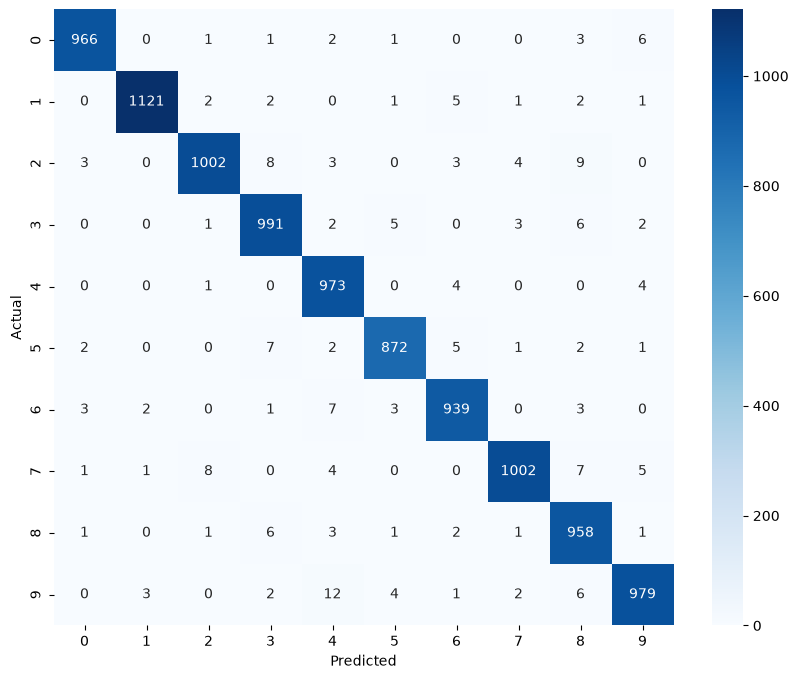

In [23]:
model.eval() 
all_targets = []
all_preds = []

with torch.no_grad(): 
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        all_targets.extend(target.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

targets = np.array(all_targets)
preds = np.array(all_preds)

cm_mnist = confusion_matrix(targets, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mnist, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1)
for epoch in range(50):
    # train_one_epoch(model, train_loader, ....)
    # val_loss = evaluate(model, val_loader)
    # scheduler.step(val_loss)
    train_loss = 0.2 * (50 - epoch)  
    scheduler.step(train_loss)

In [ ]:
# 배치정규화
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return x

In [ ]:
# 드랍아웃
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.dropout1(self.fc1(x)))
        x = F.relu(self.dropout2(self.fc2(x)))
        x = self.fc3(x)
        return x